# Insight 1 - Player Kill vs External Death

In [1]:
import pandas as pd
import pyarrow.parquet as pq
import os
from joblib import Parallel, delayed
from tqdm import tqdm
import multiprocessing

DATA_PATH = "player_data.zip"

In [2]:
def load_file(filepath):

    try:
        table = pq.read_table(filepath)
        df = table.to_pandas()

        df["event"] = df["event"].apply(
            lambda x: x.decode("utf-8") if isinstance(x, bytes) else x
        )

        return df

    except:
        return None

In [3]:
filepaths = []

for root, dirs, files in os.walk(DATA_PATH):
    for f in files:
        filepaths.append(os.path.join(root, f))

print("Total files:", len(filepaths))

Total files: 0


In [4]:
import os

os.getcwd()

'C:\\Users\\user'

In [5]:
os.listdir()

['.AltairRapidMiner',
 '.anaconda',
 '.antigravity',
 '.conda',
 '.condarc',
 '.continuum',
 '.gemini',
 '.ipynb_checkpoints',
 '.ipython',
 '.junique',
 '.jupyter',
 '.keras',
 '.matplotlib',
 '.ms-ad',
 '.spss',
 '2_FT252047_Monisha_HotelCancellation.ipynb',
 '3c33ff7f-c466-4981-927a-8fd607e8d3b0_4ff82752-ea03-47bb-bd42-efff27468078.nakama-0',
 '3D Objects',
 'ABEdata_experiment data.xlsx',
 'ABS Analysis.ipynb',
 'ABS class exercise.ipynb',
 'ABS final sheet revised.xlsx',
 'ABS final sheet.xlsx',
 'admit-with-sig-vars.ipynb',
 'anaconda3',
 'AppData',
 'Apple_Cart.ipynb',
 'Application Data',
 'BA.zip',
 'Bank Customer_v0.1.xlsx',
 'bank_full (1).csv',
 'BI Insights.pdf',
 'Contacts',
 'Cookies',
 'CrossDevice',
 'Data Handling.ipynb',
 'Data lab session 1.ipynb',
 'Data Mining - Notebook 0 - KMeans Clustering.ipynb',
 'Data Mining - Notebook 1 - CART - With onehot - Simplified version.ipynb',
 'Data Mining - Notebook 6 - ANN-latest without onehot Final 2.ipynb',
 'Desktop',
 'DM i

In [6]:
import zipfile

zip_path = "player_data.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("player_data")

In [7]:
os.listdir()

['.AltairRapidMiner',
 '.anaconda',
 '.antigravity',
 '.conda',
 '.condarc',
 '.continuum',
 '.gemini',
 '.ipynb_checkpoints',
 '.ipython',
 '.junique',
 '.jupyter',
 '.keras',
 '.matplotlib',
 '.ms-ad',
 '.spss',
 '2_FT252047_Monisha_HotelCancellation.ipynb',
 '3c33ff7f-c466-4981-927a-8fd607e8d3b0_4ff82752-ea03-47bb-bd42-efff27468078.nakama-0',
 '3D Objects',
 'ABEdata_experiment data.xlsx',
 'ABS Analysis.ipynb',
 'ABS class exercise.ipynb',
 'ABS final sheet revised.xlsx',
 'ABS final sheet.xlsx',
 'admit-with-sig-vars.ipynb',
 'anaconda3',
 'AppData',
 'Apple_Cart.ipynb',
 'Application Data',
 'BA.zip',
 'Bank Customer_v0.1.xlsx',
 'bank_full (1).csv',
 'BI Insights.pdf',
 'Contacts',
 'Cookies',
 'CrossDevice',
 'Data Handling.ipynb',
 'Data lab session 1.ipynb',
 'Data Mining - Notebook 0 - KMeans Clustering.ipynb',
 'Data Mining - Notebook 1 - CART - With onehot - Simplified version.ipynb',
 'Data Mining - Notebook 6 - ANN-latest without onehot Final 2.ipynb',
 'Desktop',
 'DM i

In [8]:
os.listdir("player_data")

['player_data']

In [9]:
os.listdir("player_data/player_data")

['.DS_Store',
 'February_10',
 'February_11',
 'February_12',
 'February_13',
 'February_14',
 'minimaps',
 'README.md']

In [10]:
DATA_PATH = "player_data/player_data"

In [11]:
import os

filepaths = []

for root, dirs, files in os.walk(DATA_PATH):
    for f in files:
        filepaths.append(os.path.join(root, f))

print("Total files:", len(filepaths))

Total files: 1248


In [12]:
import pandas as pd
import pyarrow.parquet as pq
import os
from joblib import Parallel, delayed
from tqdm import tqdm
import multiprocessing

In [13]:
DATA_PATH = "player_data/player_data"

In [14]:
filepaths = []

for root, dirs, files in os.walk(DATA_PATH):
    
    for f in files:
        
        if f.endswith(".nakama-0"):
            filepaths.append(os.path.join(root, f))

print("Total files:", len(filepaths))

Total files: 1243


In [15]:
def load_file(filepath):
    
    try:
        
        table = pq.read_table(filepath)
        df = table.to_pandas()
        
        df["event"] = df["event"].apply(
            lambda x: x.decode("utf-8") if isinstance(x, bytes) else x
        )
        
        return df
    
    except:
        return None

In [16]:
num_cores = multiprocessing.cpu_count()

dfs = Parallel(n_jobs=num_cores)(
    
    delayed(load_file)(f) for f in tqdm(filepaths)

)

dfs = [d for d in dfs if d is not None]

data = pd.concat(dfs, ignore_index=True)

print("Total rows:", len(data))

100%|█████████████████████████████████████████████████████████████████████████████| 1243/1243 [00:07<00:00, 175.36it/s]


Total rows: 89104


In [17]:
data["event"].value_counts()

event
Position         51347
BotPosition      21712
Loot             12885
BotKill           2415
BotKilled          700
KilledByStorm       39
Kill                 3
Killed               3
Name: count, dtype: int64

In [18]:
combat_events = data[
    data["event"].isin(["Kill", "KilledByStorm"])
]

In [19]:
pvp_kills = len(data[data["event"] == "Kill"])

storm_deaths = len(data[data["event"] == "KilledByStorm"])

print("PvP kills:", pvp_kills)
print("Storm deaths:", storm_deaths)

PvP kills: 3
Storm deaths: 39


In [20]:
ratio = pvp_kills / storm_deaths

print("PvP / Storm ratio:", round(ratio,2))

PvP / Storm ratio: 0.08


In [21]:
pvp_map = data[data["event"]=="Kill"].groupby("map_id").size()

storm_map = data[data["event"]=="KilledByStorm"].groupby("map_id").size()

map_comparison = pd.concat(
    [pvp_map, storm_map],
    axis=1
)

map_comparison.columns = ["PvP_Kills","Storm_Deaths"]

map_comparison

,PvP_Kills,Storm_Deaths
map_id,,
AmbroseValley,2.0,17
GrandRift,1.0,5
Lockdown,NaN,17


# Insight 2 - Combat Hotspots

In [22]:
kills = data[
    data["event"].isin(["Kill", "BotKill"])
].copy()

print("Total combat events:", len(kills))

Total combat events: 2418


In [23]:
ambrose_kills = kills[
    kills["map_id"] == "AmbroseValley"
]

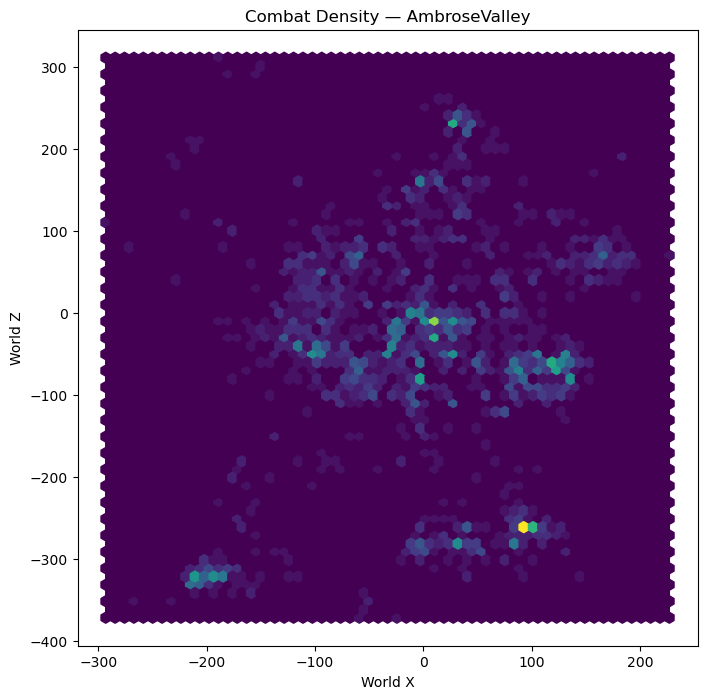

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

plt.hexbin(
    ambrose_kills["x"],
    ambrose_kills["z"],
    gridsize=60
)

plt.title("Combat Density — AmbroseValley")

plt.xlabel("World X")
plt.ylabel("World Z")

plt.show()

In [25]:
ambrose_kills["x_bin"] = pd.cut(
    ambrose_kills["x"],
    bins=30
)

ambrose_kills["z_bin"] = pd.cut(
    ambrose_kills["z"],
    bins=30
)

C:\Users\user\AppData\Local\Temp\ipykernel_27380\3693044624.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ambrose_kills["x_bin"] = pd.cut(
C:\Users\user\AppData\Local\Temp\ipykernel_27380\3693044624.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ambrose_kills["z_bin"] = pd.cut(


In [26]:
hotspots = (
    ambrose_kills
    .groupby(["x_bin","z_bin"])
    .size()
    .sort_values(ascending=False)
)

hotspots.head(10)

C:\Users\user\AppData\Local\Temp\ipykernel_27380\1671442417.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["x_bin","z_bin"])


x_bin                 z_bin               
(88.233, 105.562]     (-280.653, -257.875]    40
(122.892, 140.221]    (-75.652, -52.874]      40
(-33.073, -15.744]    (-30.096, -7.318]       35
(1.586, 18.915]       (-30.096, -7.318]       34
(105.562, 122.892]    (-75.652, -52.874]      29
(-15.744, 1.586]      (-7.318, 15.459]        28
(-206.367, -189.038]  (-326.209, -303.431]    27
(-102.391, -85.061]   (-52.874, -30.096]      26
(18.915, 36.245]      (-52.874, -30.096]      24
(-33.073, -15.744]    (-52.874, -30.096]      23
dtype: int64

In [27]:
kills.groupby("map_id").size()

map_id
AmbroseValley    1799
GrandRift         193
Lockdown          426
dtype: int64

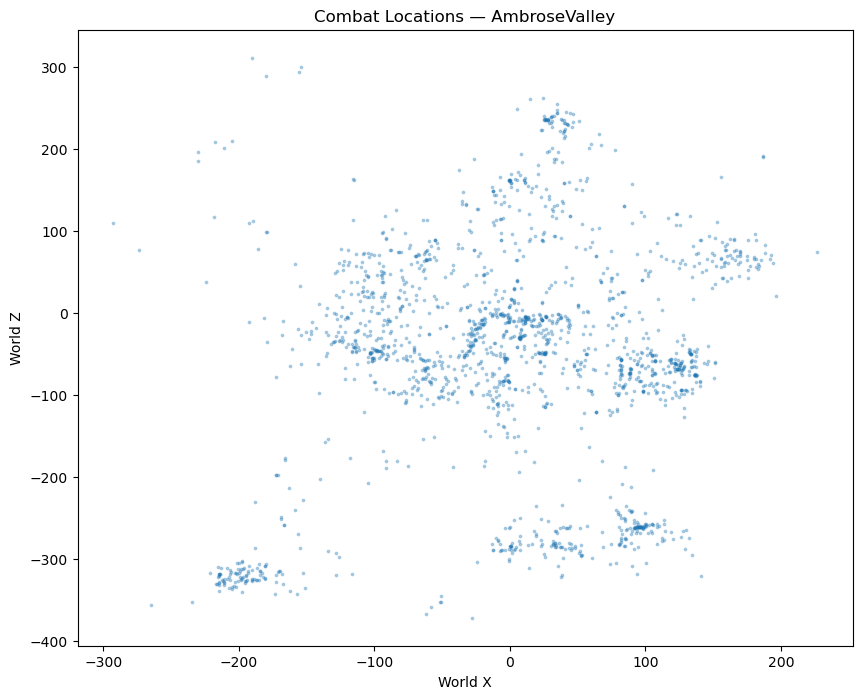

In [28]:
plt.figure(figsize=(10,8))

plt.scatter(
    ambrose_kills["x"],
    ambrose_kills["z"],
    s=3,
    alpha=0.3
)

plt.title("Combat Locations — AmbroseValley")

plt.xlabel("World X")
plt.ylabel("World Z")

plt.show()

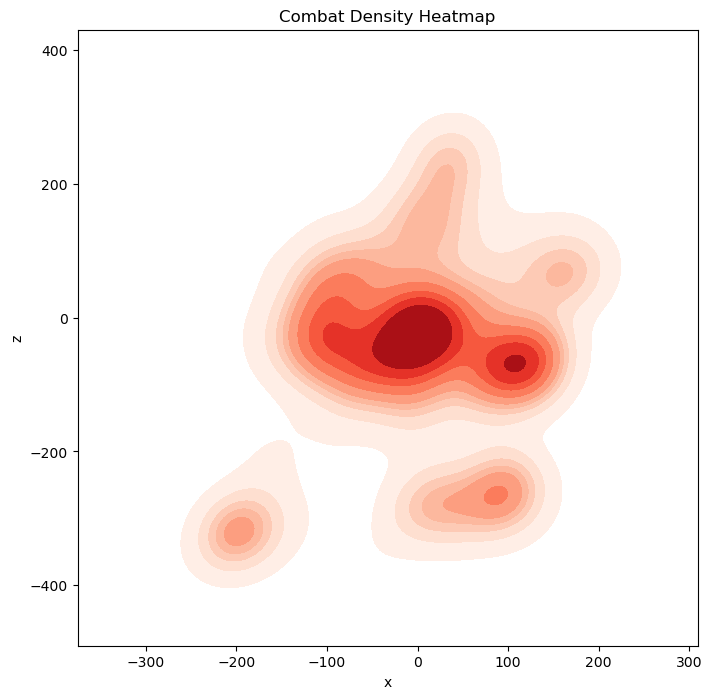

In [29]:
import seaborn as sns

plt.figure(figsize=(8,8))

sns.kdeplot(
    x=ambrose_kills["x"],
    y=ambrose_kills["z"],
    fill=True,
    cmap="Reds",
    thresh=0.05
)

plt.title("Combat Density Heatmap")

plt.show()

# Insight 3 - Player Survival Curve

In [30]:
deaths = data[
    data["event"].isin(["Killed", "BotKilled", "KilledByStorm"])
].copy()

print("Total deaths:", len(deaths))

Total deaths: 742


In [31]:
deaths["match_time"] = deaths.groupby("match_id")["ts"].transform(
    lambda x: (x - x.min()).dt.total_seconds()
)

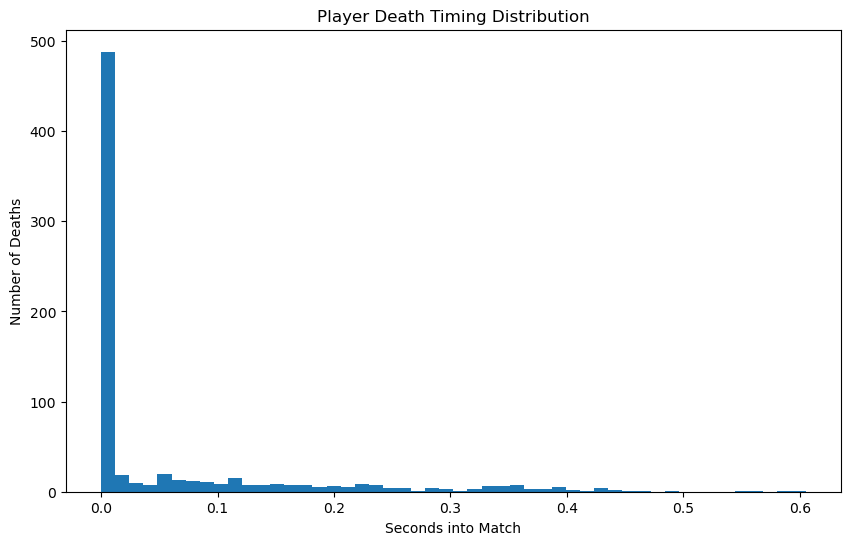

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.hist(
    deaths["match_time"],
    bins=50
)

plt.title("Player Death Timing Distribution")

plt.xlabel("Seconds into Match")
plt.ylabel("Number of Deaths")

plt.show()

In [33]:
early_deaths = deaths[deaths["match_time"] < 120]

mid_deaths = deaths[
    (deaths["match_time"] >= 120) &
    (deaths["match_time"] < 300)
]

late_deaths = deaths[deaths["match_time"] >= 300]

print("Early deaths:", len(early_deaths))
print("Mid deaths:", len(mid_deaths))
print("Late deaths:", len(late_deaths))

Early deaths: 742
Mid deaths: 0
Late deaths: 0


In [34]:
match_duration = data.groupby("match_id")["ts"].max()

match_duration_seconds = (
    match_duration - data.groupby("match_id")["ts"].min()
).dt.total_seconds()

print("Average match duration (seconds):", match_duration_seconds.mean())

Average match duration (seconds): 0.40842336683417085


In [35]:
deaths_by_map = deaths.groupby("map_id")["match_time"].mean()

print(deaths_by_map)

map_id
AmbroseValley    0.051297
GrandRift        0.023423
Lockdown         0.094178
Name: match_time, dtype: float64


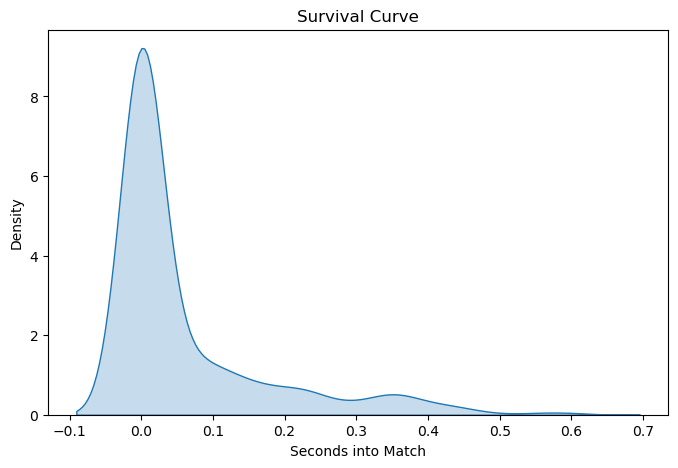

In [36]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.kdeplot(
    data=deaths,
    x="match_time",
    fill=True
)

plt.title("Survival Curve")

plt.xlabel("Seconds into Match")

plt.show()